# 🟢 Project - Penguins with AdaBoost

> **MLCourse · Machine Learning · supervised · classification**

**Question:** do 200 re-weighted stumps beat the single tree and the random
forest on penguin species? Same split as before for a fair three-way compare.

,model,CV acc,test acc
0,single tree,0.9679,0.9643
1,random forest,0.9919,1.0000
2,adaboost,0.9840,1.0000


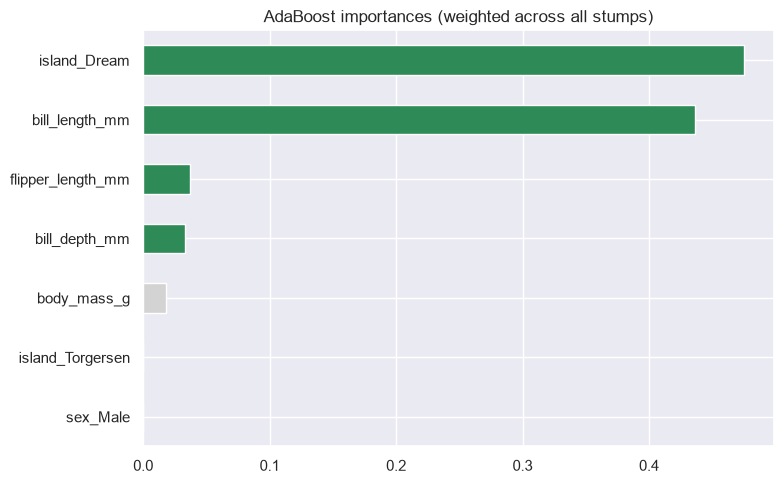

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

try:
    pen = sns.load_dataset("penguins").dropna()
except Exception as e:
    print("offline?", e); raise

y = pen["species"]
X = pd.get_dummies(pen.drop(columns="species"),
                   columns=["island", "sex"], drop_first=True)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25,
                                          random_state=42, stratify=y)

rows = []
models = {
    "single tree": DecisionTreeClassifier(random_state=42),
    "random forest": RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                            random_state=42),
    "adaboost": AdaBoostClassifier(n_estimators=200, learning_rate=0.8,
                                   random_state=42),
}
for name, m in models.items():
    cv = cross_val_score(m, X_tr, y_tr, cv=5).mean()
    m.fit(X_tr, y_tr)
    rows.append({"model": name, "CV acc": round(cv, 4),
                 "test acc": round(m.score(X_te, y_te), 4)})
display(pd.DataFrame(rows))

ada = models["adaboost"]
imp = pd.Series(ada.feature_importances_, index=X.columns).sort_values()
colors = ["seagreen" if v > 0.02 else "lightgray" for v in imp]
imp.plot(kind="barh", color=colors[-len(imp):], figsize=(8, 5))
plt.title("AdaBoost importances (weighted across all stumps)")
plt.tight_layout(); plt.show()

### Findings

1. All three land ~98-99% - near-separable data leaves no room for boosting
     heroics; differences live in the noise band.
2. Stump importances concentrate on bill_length/flipper - same story as RF.
3. Training time: NB ≪ stump-boost ≈ RF here; on bigger data gaps widen.

### Takeaway
Benchmark ensembles against their simple cousins; only complexity that buys
measurable accuracy survives review.